# Reproduce Figure 26 from Noah's paper.

In [1]:
import sys, os
sys.path.append('../MultiFishLSS/')
from headers import *
from twoPoint import *
from twoPointNoise import *
from classy import Class

import matplotlib.pyplot as plt

import matplotlib
from matplotlib.pyplot import rc
import matplotlib.font_manager

rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
rc('mathtext', **{'fontset':'cm'})
rc('text', usetex=True)
rc('legend',**{'fontsize':'18'})

matplotlib.rcParams['axes.linewidth'] = 3
matplotlib.rcParams['axes.labelsize'] = 30
matplotlib.rcParams['xtick.labelsize'] = 25 
matplotlib.rcParams['ytick.labelsize'] = 25
matplotlib.rcParams['legend.fontsize'] = 25
matplotlib.rcParams['xtick.major.size'] = 10
matplotlib.rcParams['ytick.major.size'] = 10
matplotlib.rcParams['xtick.minor.size'] = 5
matplotlib.rcParams['ytick.minor.size'] = 5
matplotlib.rcParams['xtick.major.width'] = 3
matplotlib.rcParams['ytick.major.width'] = 3
matplotlib.rcParams['xtick.minor.width'] = 1.5
matplotlib.rcParams['ytick.minor.width'] = 1.5
matplotlib.rcParams['axes.titlesize'] = 30
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

import os
os.environ["PATH"] += os.pathsep + "/usr/local/texlive/2020/bin/x86_64-darwin"

In [2]:
params = {'output': 'mPk lCl','P_k_max_h/Mpc': 40.,'non linear':'halofit', 
          'z_pk': '0.0,10','A_s': 2.10732e-9,'n_s': 0.96824,
          'alpha_s': 0.,'h': 0.6770, 'N_ur': 1.0196,
          'N_ncdm': 2,'m_ncdm': '0.01,0.05','tau_reio': 0.0568,
          'omega_b': 0.02247,'omega_cdm': 0.11923,'Omega_k': 0.}
cosmo = Class()
cosmo.set(params)
cosmo.compute()

## Build wigglesplit forecast.

In [3]:
bd = './' # replace with where you want to save derivatives (will create bdir/output/bfn/)
nbins = 4

zs = np.array([0.65,0.75,0.85,0.95,1.05,1.15,1.25,1.35,1.45,1.55,1.65])
dNdz = np.array([309,2269,1923,2094,1441,1353,1337,523,466,329,126])
N = 41252.96125 * dNdz * 0.1 # number of emitters in dz=0.1 across the whole sky
volume = np.array([((1.+z+0.05)*cosmo.angular_distance(z+0.05))**3. for z in zs])
volume -= np.array([((1.+z-0.05)*cosmo.angular_distance(z-0.05))**3. for z in zs])
volume *= 4.*np.pi*cosmo.pars['h']**3./3. # volume in Mpc^3/h^3
n = list(N/volume)
zs = np.array([0.6,0.65,0.75,0.85,0.95,1.05,1.15,1.25,1.35,1.45,1.55,1.65,1.7])
n = [n[0]] + n
n = n + [n[-1]]
n = np.array(n)
n_interp = interp1d(zs, n, kind='linear', bounds_error=False, fill_value=0.)

b = lambda z: 0.84/cosmo.scale_independent_growth_factor(z)

exp = experiment(zmin=0.6, zmax=1.7, nbins=nbins, n=n_interp, b=b, fsky=0.34)

recon = 'wigglesplit'

bfn = 'reproduce_fishlss_desi_elg_{}'.format(recon)

wsforecast = fisherForecast(experiment=exp,cosmo=cosmo,name=bfn,basedir=bd, recon=recon, overwrite=True)

Initialising fiducial Pk with recon = wigglesplit and self.recon = False
Finished computing fiducial Pk, setting self.recon = wigglesplit
Initialising fiducial Precon with recon = wigglesplit and self.recon = wigglesplit
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 1.2240177663051561,1.2240177663051561
sigmaS = 2.0 
 sigmaPar = 3.653911887951564 
 sigmaPerp = 2.005733081732169 
 r = 0.5 
 ba = 1.2240177663051561 
 bb = 1.2240177663051561 
 f = 0.8217338693920396 
 alpha_parallel = 1.0 
 alpha_perp = 1.0 
 ap_deriv = False
Using simpson integration
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 1.3866383708463743,1.3866383708463743
sigmaS = 2.0 
 sigmaPar = 3.317778194788212 
 sigmaPerp = 1.7705069887887601 
 r = 0.5 
 ba = 1.3866383708463743 
 bb = 1.3866383708463743 
 f = 0.8739142041218212 
 alpha_parallel = 1.0 
 alpha_perp = 1.0 
 ap_deriv = False
Using simpson integration
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 1.5544596662948893,1.5544596662948893
sigmaS = 2.0 
 sigmaPar = 3.107852804503231 
 sigmaPe

In [4]:
%reload_ext autoreload
%autoreload 2

basis = np.array(['alpha_parallel','alpha_perp','b', 'f'])

wsforecast.free_params = basis
wsforecast.compute_derivatives(overwrite=True) # will not overwrite unless specified

wsF = lambda i: wsforecast.gen_fisher(basis, 100, zbins=np.array([i]))
wsFs = np.array([wsF(i) for i in range(nbins)])

alpha_parallel in kwargs
alpha_parallel default_value = 1.0
b, ba,bb = -1.0,1.2240177663051561,1.2240177663051561
WS ba,bb = 1.2240177663051561,1.2240177663051561
sigmaS = 2.0 
 sigmaPar = 3.653911887951564 
 sigmaPerp = 2.005733081732169 
 r = 0.5 
 ba = 1.2240177663051561 
 bb = 1.2240177663051561 
 f = 0.8217338693920396 
 alpha_parallel = 1.01 
 alpha_perp = 1.0 
 ap_deriv = True
Using simpson integration
b, ba,bb = -1.0,1.2240177663051561,1.2240177663051561
WS ba,bb = 1.2240177663051561,1.2240177663051561
sigmaS = 2.0 
 sigmaPar = 3.653911887951564 
 sigmaPerp = 2.005733081732169 
 r = 0.5 
 ba = 1.2240177663051561 
 bb = 1.2240177663051561 
 f = 0.8217338693920396 
 alpha_parallel = 0.99 
 alpha_perp = 1.0 
 ap_deriv = True
Using simpson integration
b, ba,bb = -1.0,1.2240177663051561,1.2240177663051561
WS ba,bb = 1.2240177663051561,1.2240177663051561
sigmaS = 2.0 
 sigmaPar = 3.653911887951564 
 sigmaPerp = 2.005733081732169 
 r = 0.5 
 ba = 1.2240177663051561 
 bb = 1.2240177663

In [5]:
wsFinvs = [np.linalg.inv(wsFs[i]) for i in range(nbins)]
ws_sigma_a_par = np.array([np.sqrt(wsFinvs[i][0,0]) for i in range(nbins)])
ws_sigma_a_perp = np.array([np.sqrt(wsFinvs[i][1,1]) for i in range(nbins)])

print('Relative error on a_par:',ws_sigma_a_par)
print('Relative error on a_perp:',ws_sigma_a_perp)

Relative error on a_par: [0.00925301 0.00739178 0.00843225 0.01888818]
Relative error on a_perp: [0.00645492 0.00553946 0.00672795 0.01640426]


## Build LPT forecast.

In [6]:
recon = 'LPT'

bfn = 'reproduce_fishlss_desi_elg_{}'.format(recon)

lptforecast = fisherForecast(experiment=exp,cosmo=cosmo,name=bfn,basedir=bd, recon=recon, overwrite=True)

Initialising fiducial Pk with recon = LPT and self.recon = False
Finished computing fiducial Pk, setting self.recon = LPT
Initialising fiducial Precon with recon = LPT and self.recon = LPT
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 1.2240177663051561,1.2240177663051561
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 1.3866383708463743,1.3866383708463743
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 1.5544596662948893,1.5544596662948893
b, ba,bb = -1.0,-1.0,-1.0
WS ba,bb = 1.7257058573982056,1.7257058573982056
Finished computing fiducial Precon, setting self.recon = LPT


In [8]:
lptforecast.free_params = basis
lptforecast.compute_derivatives(overwrite=True) # will not overwrite unless specified

lptF = lambda i: lptforecast.gen_fisher(basis, 100,zbins=np.array([i]))
lptFs = np.array([lptF(i) for i in range(nbins)])

b, ba,bb = -1.0,1.2240177663051561,1.2240177663051561
WS ba,bb = 1.2240177663051561,1.2240177663051561
alpha_parallel in kwargs
alpha_parallel default_value = 1.0
b, ba,bb = -1.0,1.2240177663051561,1.2240177663051561
WS ba,bb = 1.2240177663051561,1.2240177663051561
alpha_perp in kwargs
alpha_perp default_value = 1.0
b, ba,bb = 1.2240177663051561,-1.0,-1.0
WS ba,bb = 1.2240177663051561,1.2240177663051561
b in kwargs
b default_value = 1.2240177663051561
b, ba,bb = 1.2362579439682078,-1.0,-1.0
WS ba,bb = 1.2362579439682078,1.2362579439682078
b, ba,bb = 1.2117775886421045,-1.0,-1.0
WS ba,bb = 1.2117775886421045,1.2117775886421045
b, ba,bb = 1.2484981216312592,-1.0,-1.0
WS ba,bb = 1.2484981216312592,1.2484981216312592
b, ba,bb = 1.199537410979053,-1.0,-1.0
WS ba,bb = 1.199537410979053,1.199537410979053
b, ba,bb = -1.0,1.2240177663051561,1.2240177663051561
WS ba,bb = 1.2240177663051561,1.2240177663051561
f in kwargs
f default_value = 0.8217338693920396
b, ba,bb = -1.0,1.2240177663051561,1.22

In [9]:
lptFinvs = [np.linalg.inv(lptFs[i]) for i in range(nbins)]
lpt_sigma_a_par = np.array([np.sqrt(lptFinvs[i][0,0]) for i in range(nbins)])
lpt_sigma_a_perp = np.array([np.sqrt(lptFinvs[i][1,1]) for i in range(nbins)])

print('Relative error on a_par:',lpt_sigma_a_par)
print('Relative error on a_perp:',lpt_sigma_a_perp)

Relative error on a_par: [0.00962769 0.00834608 0.00971419 0.01982589]
Relative error on a_perp: [0.00654847 0.00586014 0.0072576  0.01658557]


## Plot the constraints.

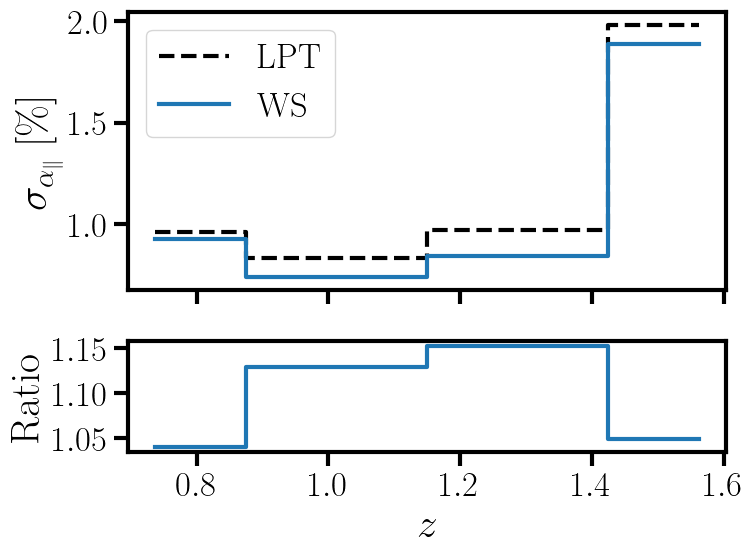

In [10]:
zs = exp.zcenters

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [2.5, 1]},  # Top is 2x taller
    figsize=(8, 6)
)

ax1.step(zs, 100*lpt_sigma_a_par, color='black', ls='--', lw=3, label=r'LPT', where='mid')
ax1.step(zs, 100*ws_sigma_a_par, ls='-', lw=3, label=r'WS', where='mid')

ax1.set_ylabel(r'$\sigma_{\alpha_\|} \; [\%]$')
ax1.legend()

ax2.step(zs, lpt_sigma_a_par/ws_sigma_a_par, lw=3, where='mid')
ax2.set_ylabel('Ratio')
ax2.set_xlabel(r'$z$')

plt.tight_layout()


#plt.savefig('/Users/makaibaker/Dropbox/2026/Berkeley/Research/sigmaAP_par_comparison.pdf')

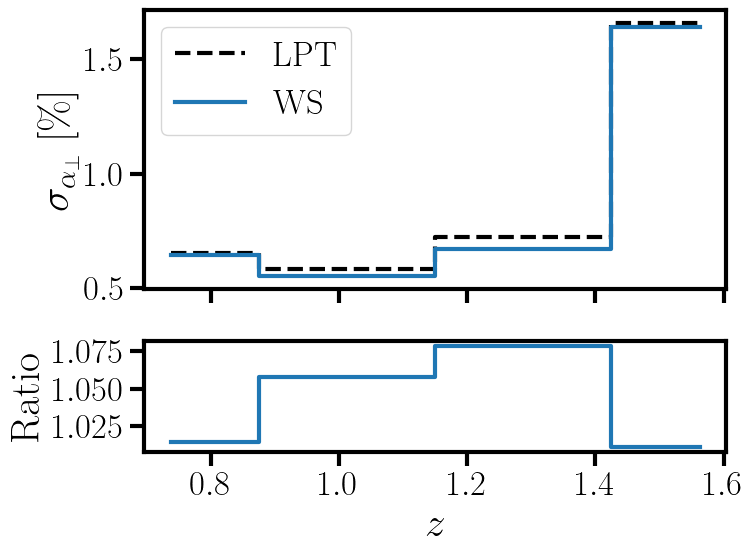

In [11]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [2.5, 1]},  # Top is 2x taller
    figsize=(8, 6)
)

ax1.step(zs, 100*lpt_sigma_a_perp, color='black', ls='--', lw=3, label=r'LPT', where='mid')
ax1.step(zs, 100*ws_sigma_a_perp, ls='-', lw=3, label=r'WS', where='mid')

ax1.set_ylabel(r'$\sigma_{\alpha_\perp} \; [\%]$')
ax1.legend()

ax2.step(zs, lpt_sigma_a_perp/ws_sigma_a_perp, lw=3, where='mid')
ax2.set_ylabel('Ratio')
ax2.set_xlabel(r'$z$')

plt.tight_layout()

#plt.savefig('/Users/makaibaker/Dropbox/2026/Berkeley/Research/sigmaAP_perp_comparison.pdf')

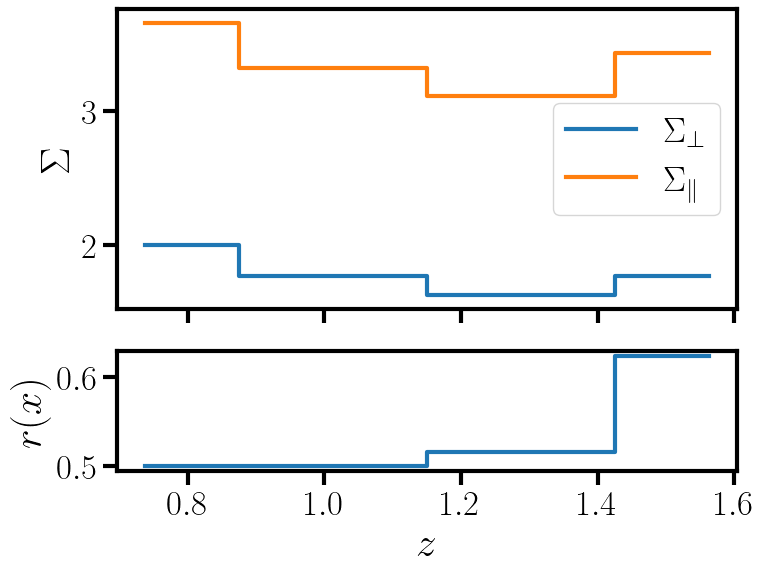

In [12]:
sigma_perps = np.array([2.005733081732169, 1.7705069887887601,1.6284769052816799, 1.7732275674574387])
sigma_pars = np.array([3.653911887951564, 3.317778194788212,3.107852804503231 ,3.42530339118227])
rs = np.array([0.5, 0.5, 0.5155493063759691, 0.6232185804678594])

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [2.5, 1]},  # Top is 2x taller
    figsize=(8, 6)
)

ax1.step(zs, sigma_perps, lw=3, label=r'$\Sigma_\perp$', where='mid')
ax1.step(zs, sigma_pars, lw=3, label=r'$\Sigma_\|$', where='mid')
ax1.set_ylabel(r'$\Sigma$')
ax1.legend()

ax2.step(zs, rs, lw=3, where='mid')
ax2.set_ylabel(r'$r(x)$')
ax2.set_xlabel(r'$z$')

plt.show()

In [13]:
sigma_a_par_no_ap = np.array([0.00958726, 0.00834476, 0.00970467, 0.01977781])
sigma_a_perp_no_ap = np.array([0.00650459, 0.00585279, 0.00723478, 0.01658505])

sigma_a_par_ap = np.array([0.00917942, 0.00729325, 0.00843489, 0.0188309 ])
sigma_a_perp_ap = np.array([0.00642344, 0.00547482, 0.00677579, 0.01639133])

In [14]:
print(np.mean(np.abs(100*(sigma_a_par_no_ap-sigma_a_par_ap))))
print(np.mean(np.abs(100*(sigma_a_perp_no_ap-sigma_a_perp_ap))))

0.09190099999999993
0.02779575000000003


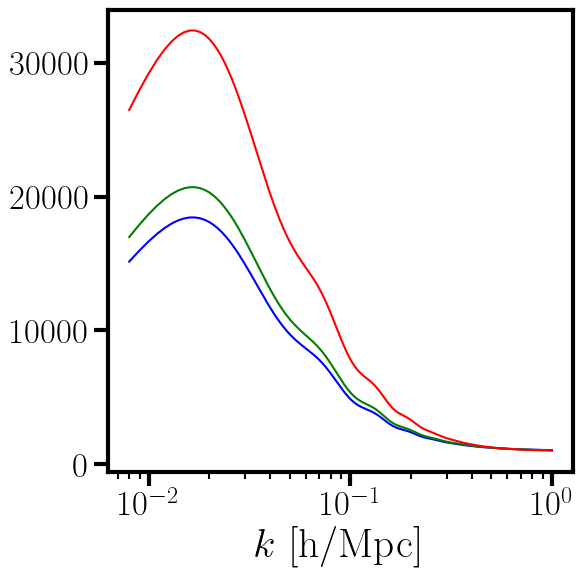

pfid_gg_74.txt


<Figure size 640x480 with 0 Axes>

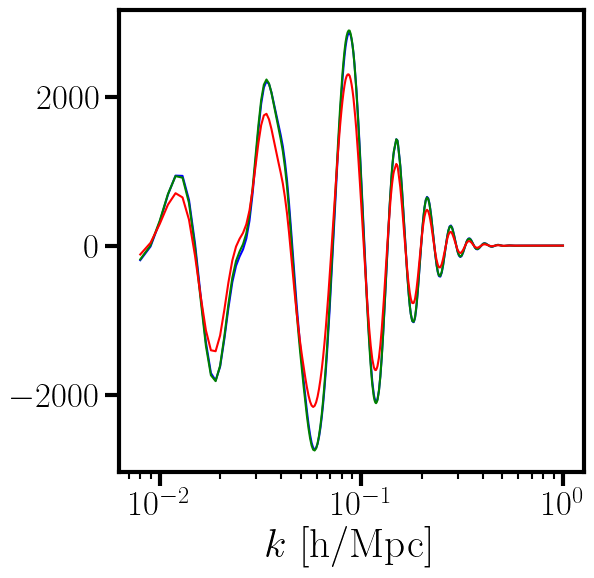

Pgg_alpha_perp_156.txt


<Figure size 640x480 with 0 Axes>

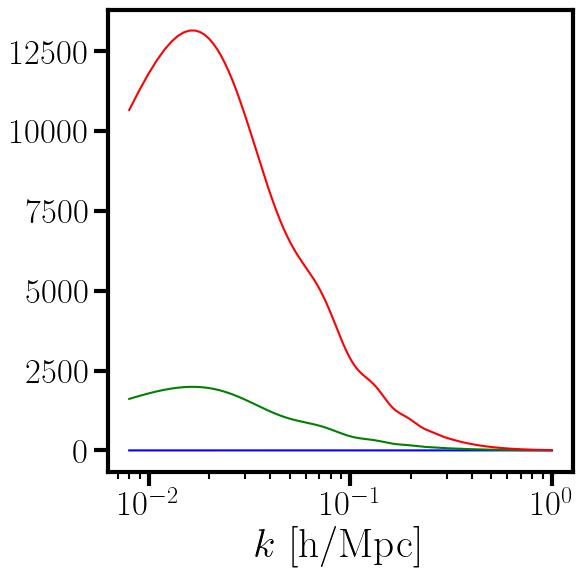

Pgg_f_156.txt


<Figure size 640x480 with 0 Axes>

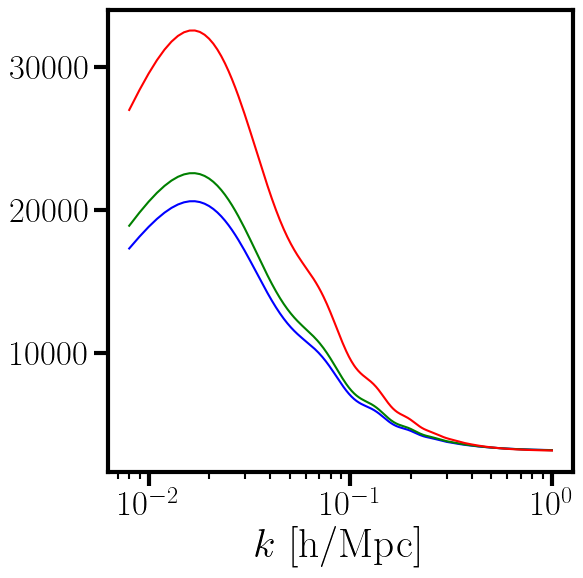

pfid_gg_129.txt


<Figure size 640x480 with 0 Axes>

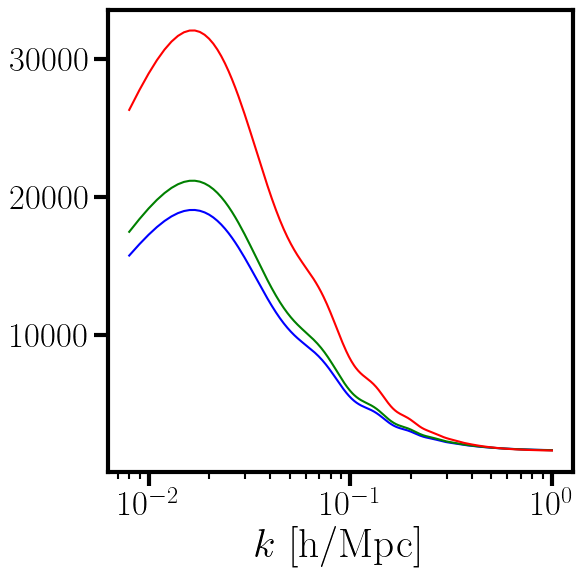

pfid_gg_101.txt


<Figure size 640x480 with 0 Axes>

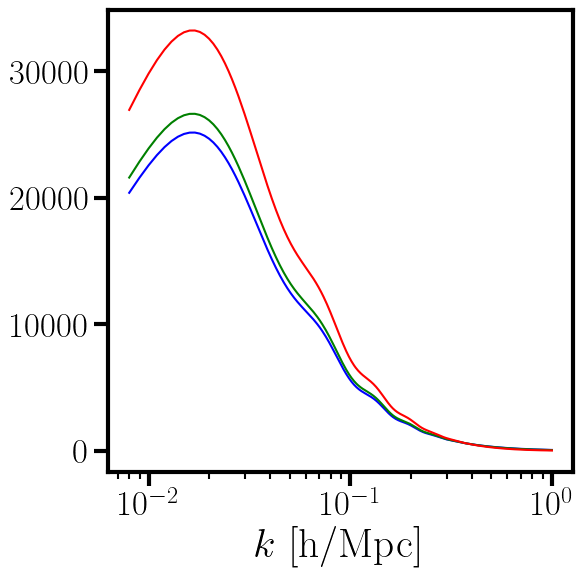

Pgg_bg_101.txt


<Figure size 640x480 with 0 Axes>

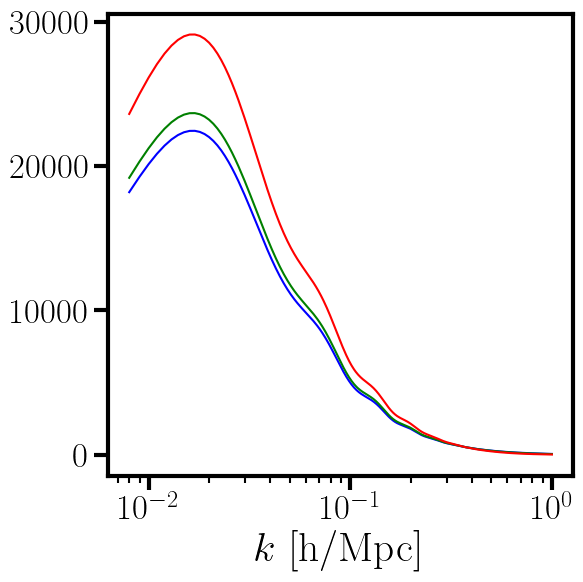

Pgg_bg_129.txt


<Figure size 640x480 with 0 Axes>

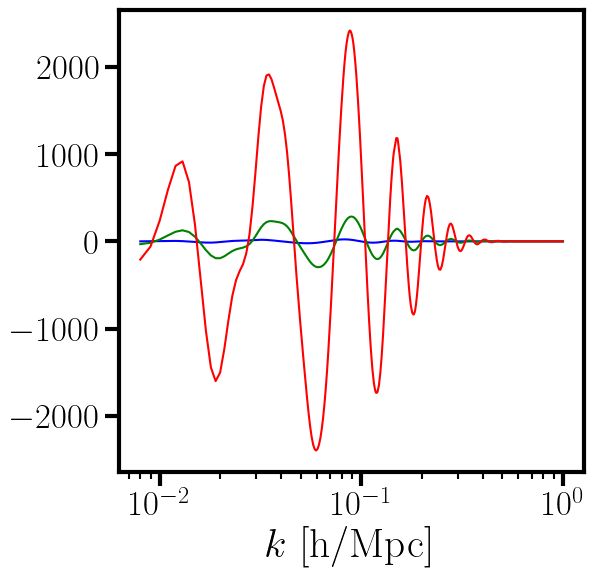

Pgg_alpha_parallel_129.txt


<Figure size 640x480 with 0 Axes>

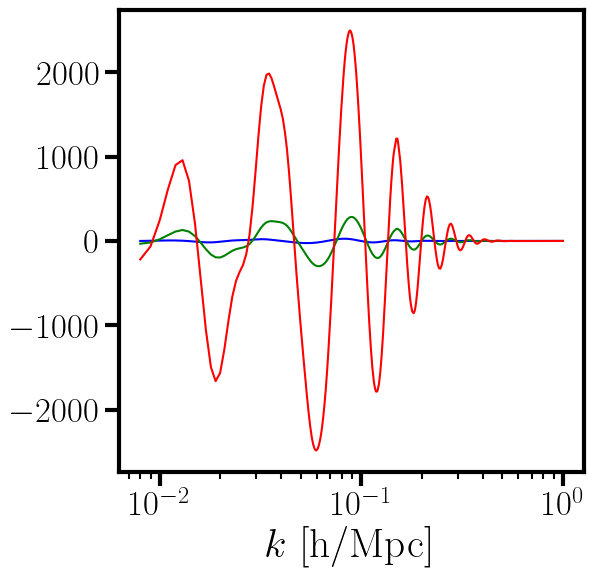

Pgg_alpha_parallel_101.txt


<Figure size 640x480 with 0 Axes>

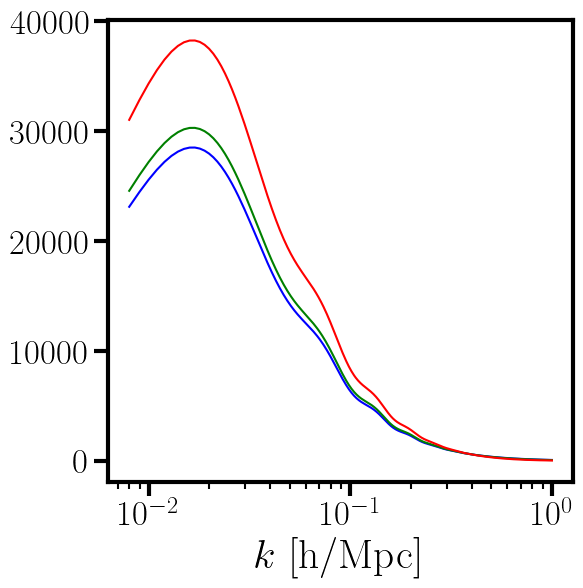

Pgg_bg_74.txt


<Figure size 640x480 with 0 Axes>

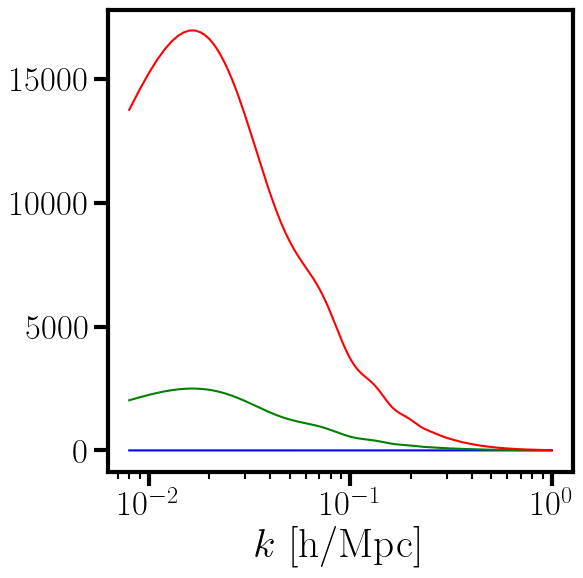

Pgg_f_101.txt


<Figure size 640x480 with 0 Axes>

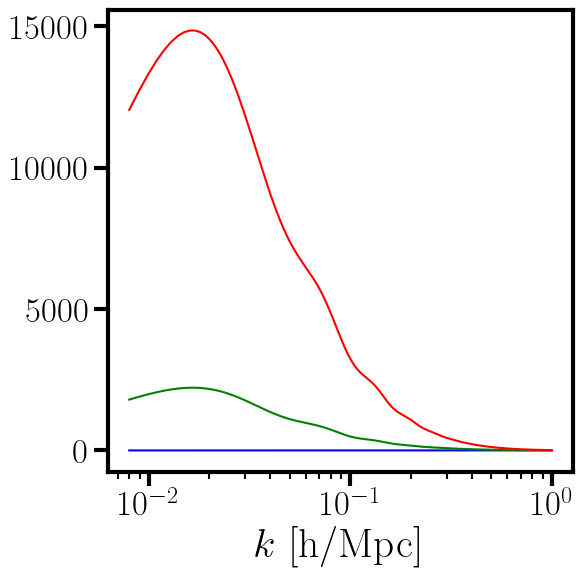

Pgg_f_129.txt


<Figure size 640x480 with 0 Axes>

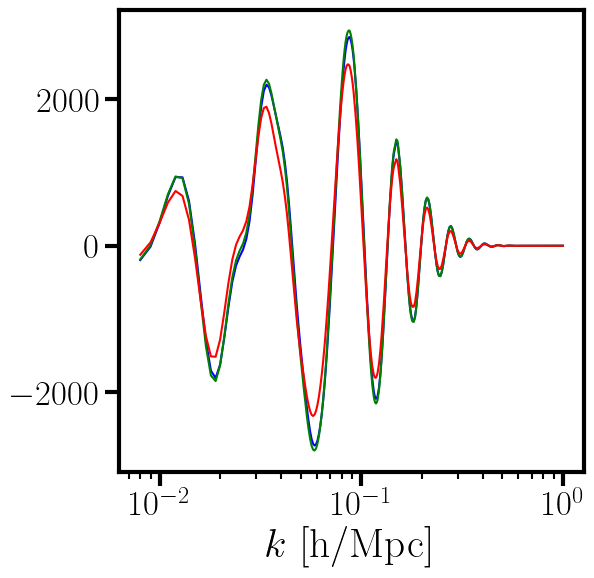

Pgg_alpha_perp_101.txt


<Figure size 640x480 with 0 Axes>

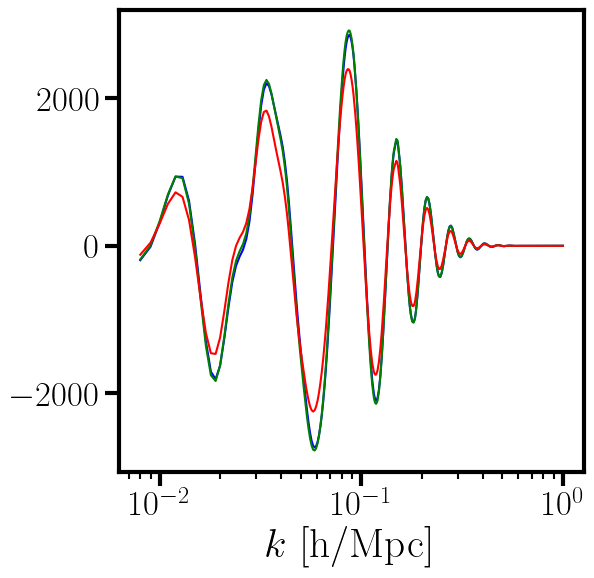

Pgg_alpha_perp_129.txt


<Figure size 640x480 with 0 Axes>

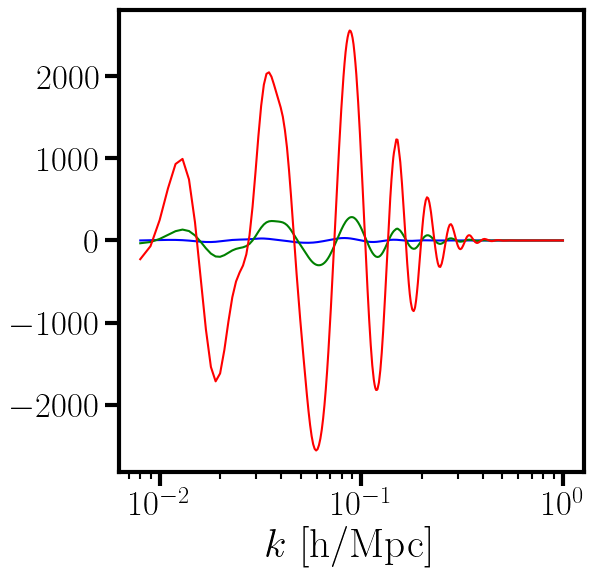

Pgg_alpha_parallel_74.txt


<Figure size 640x480 with 0 Axes>

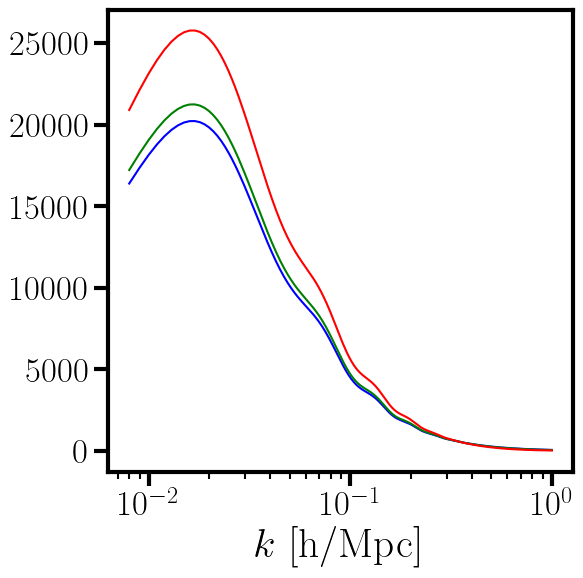

Pgg_bg_156.txt


<Figure size 640x480 with 0 Axes>

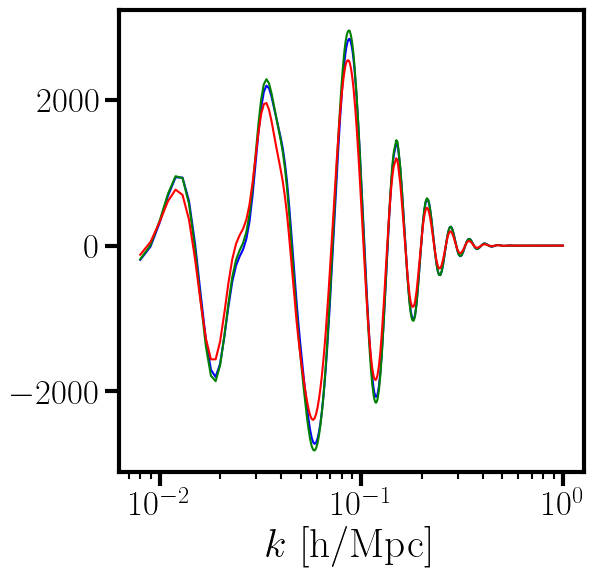

Pgg_alpha_perp_74.txt


<Figure size 640x480 with 0 Axes>

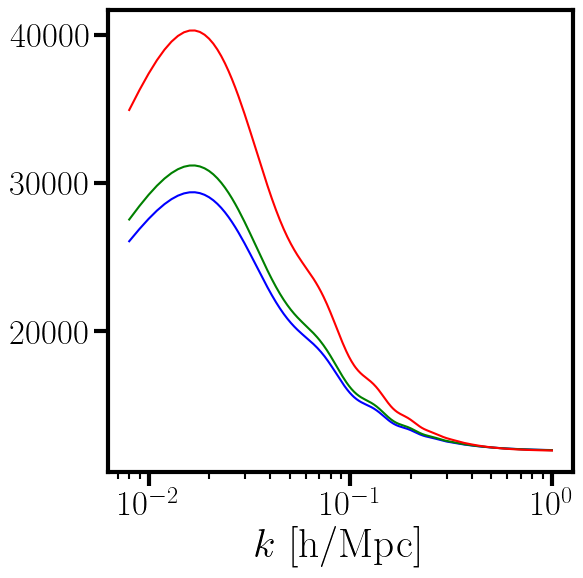

pfid_gg_156.txt


<Figure size 640x480 with 0 Axes>

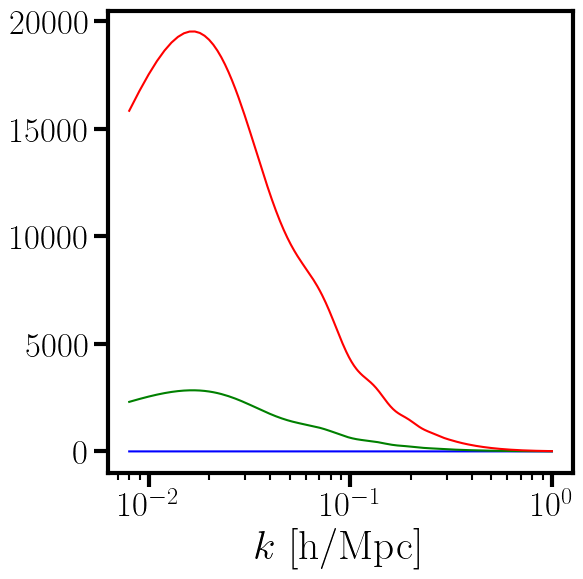

Pgg_f_74.txt


<Figure size 640x480 with 0 Axes>

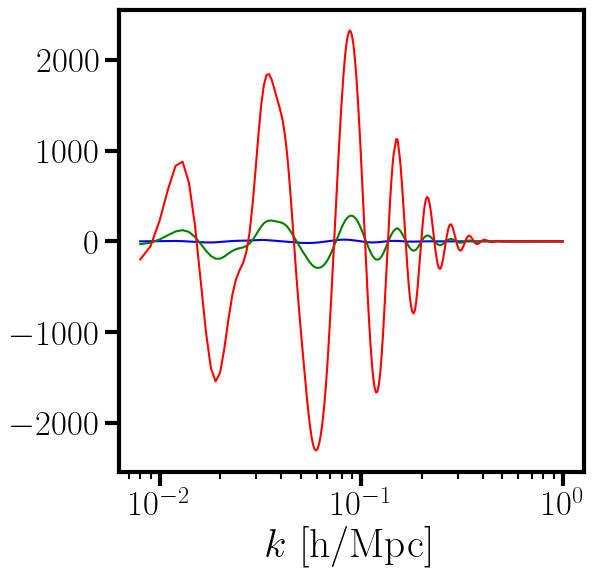

Pgg_alpha_parallel_156.txt


<Figure size 640x480 with 0 Axes>

In [15]:
wsforecast.check_derivatives()

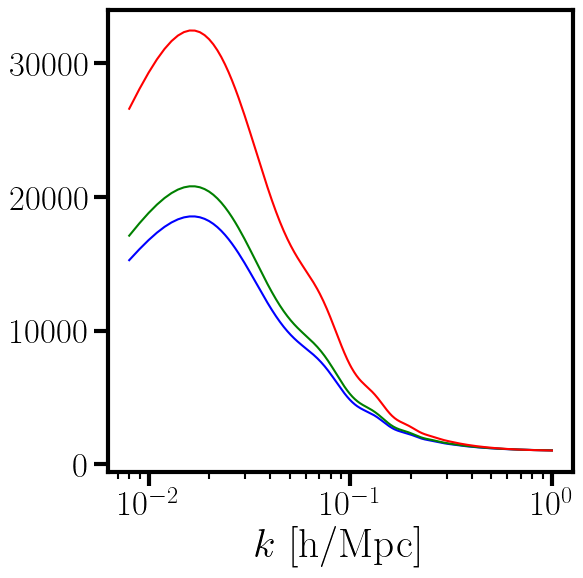

pfid_gg_74.txt


<Figure size 640x480 with 0 Axes>

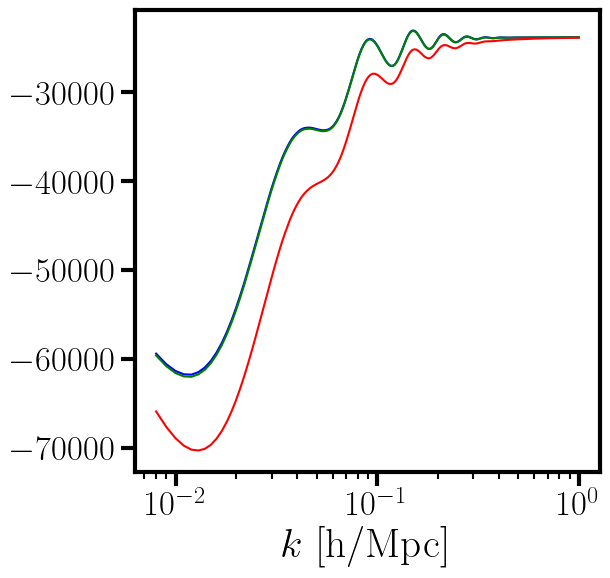

Pgg_alpha_perp_156.txt


<Figure size 640x480 with 0 Axes>

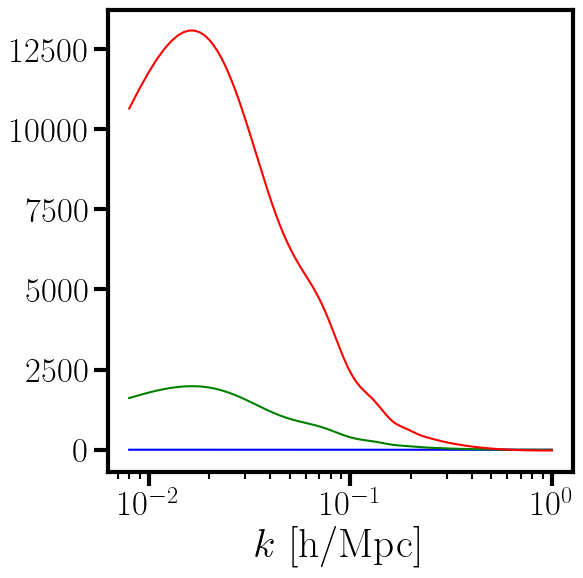

Pgg_f_156.txt


<Figure size 640x480 with 0 Axes>

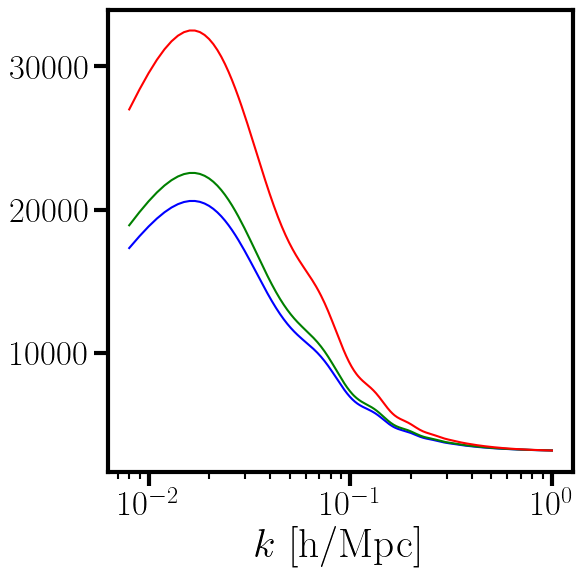

pfid_gg_129.txt


<Figure size 640x480 with 0 Axes>

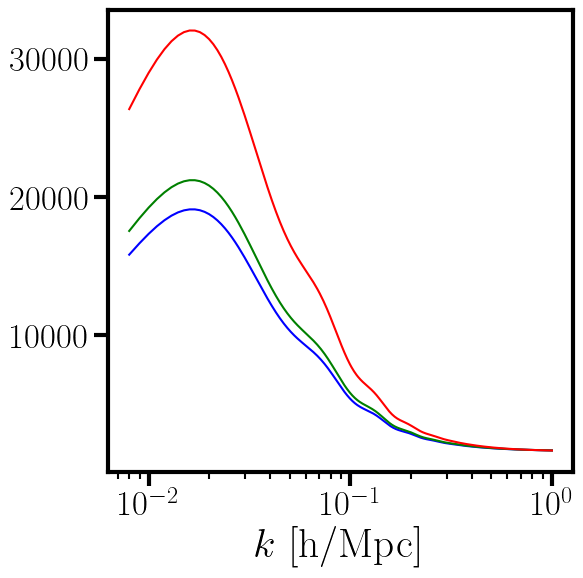

pfid_gg_101.txt


<Figure size 640x480 with 0 Axes>

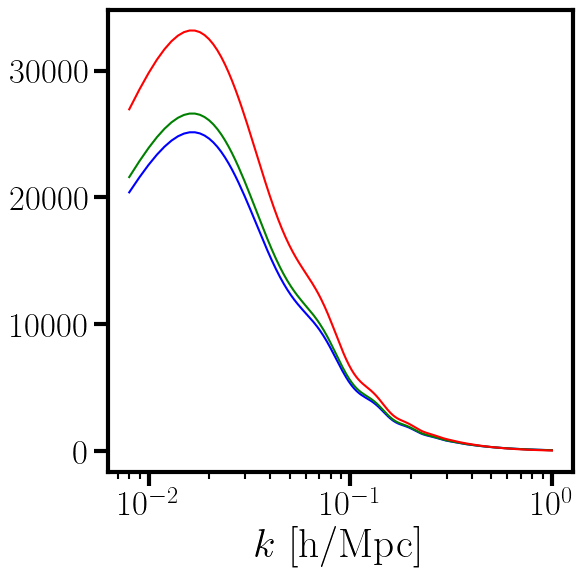

Pgg_bg_101.txt


<Figure size 640x480 with 0 Axes>

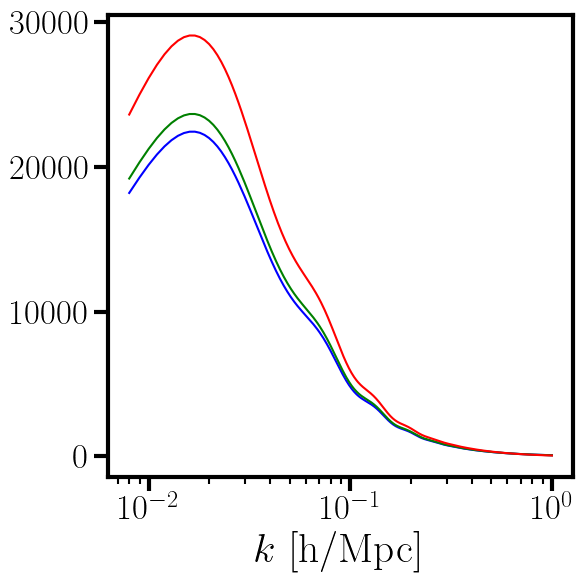

Pgg_bg_129.txt


<Figure size 640x480 with 0 Axes>

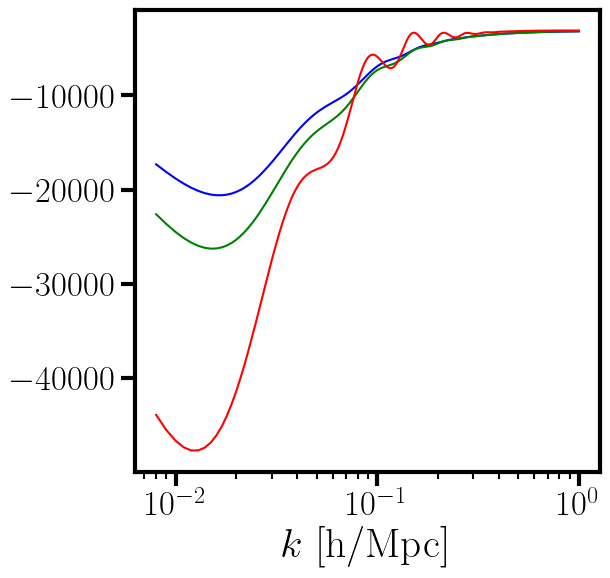

Pgg_alpha_parallel_129.txt


<Figure size 640x480 with 0 Axes>

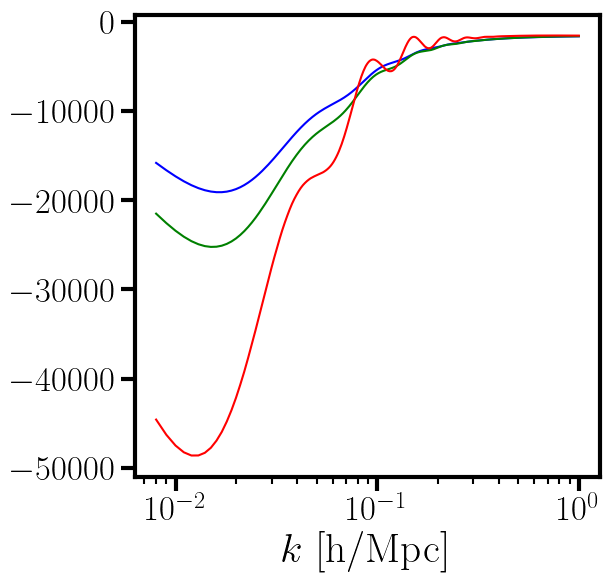

Pgg_alpha_parallel_101.txt


<Figure size 640x480 with 0 Axes>

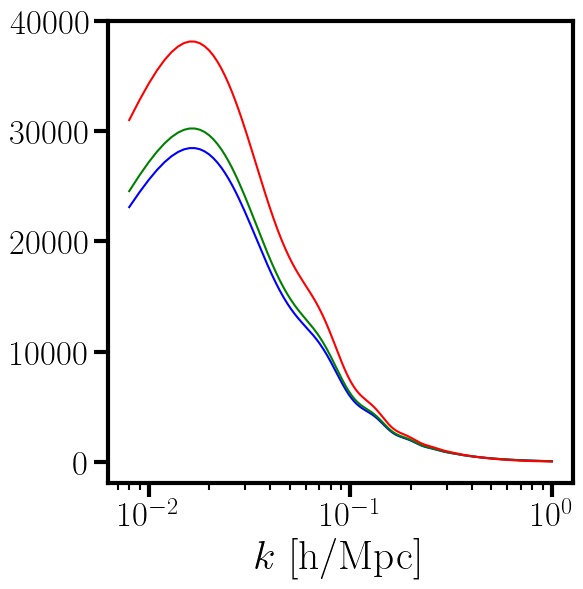

Pgg_bg_74.txt


<Figure size 640x480 with 0 Axes>

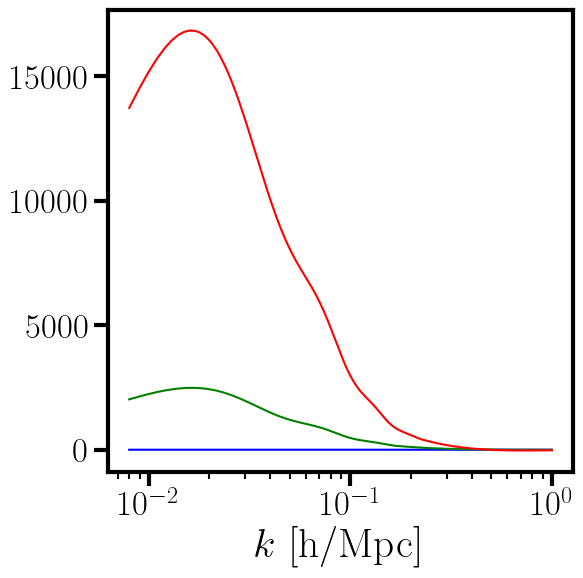

Pgg_f_101.txt


<Figure size 640x480 with 0 Axes>

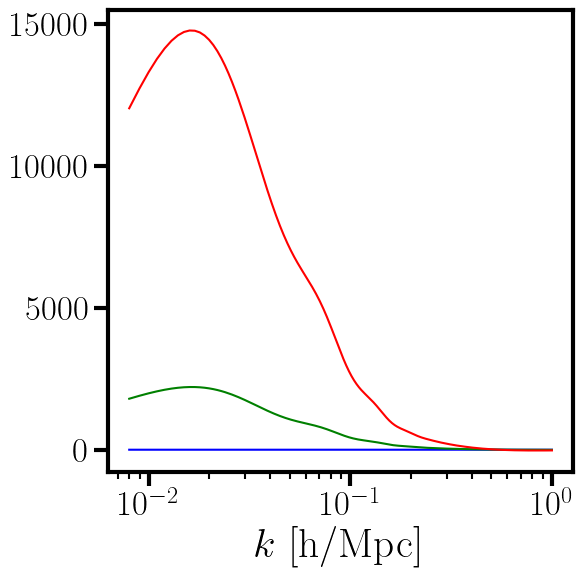

Pgg_f_129.txt


<Figure size 640x480 with 0 Axes>

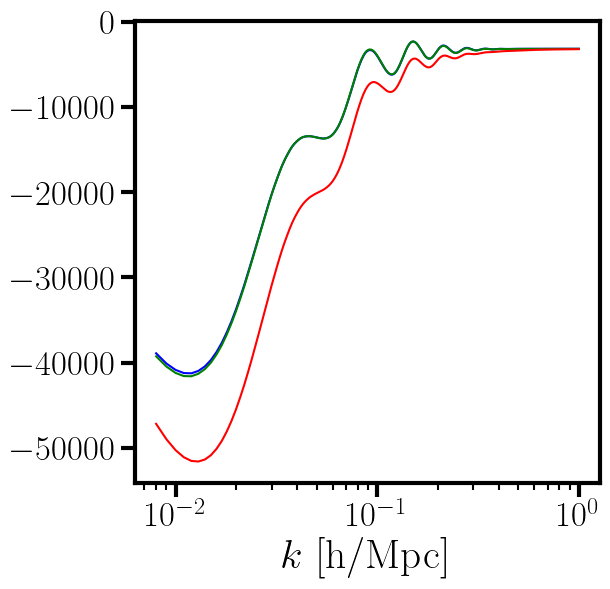

Pgg_alpha_perp_101.txt


<Figure size 640x480 with 0 Axes>

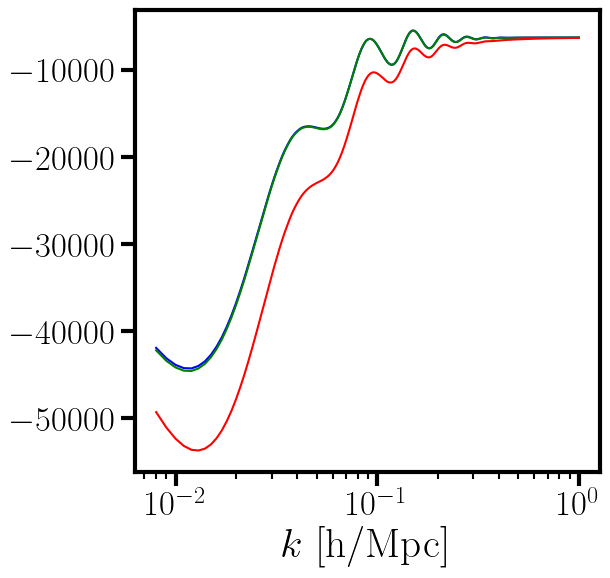

Pgg_alpha_perp_129.txt


<Figure size 640x480 with 0 Axes>

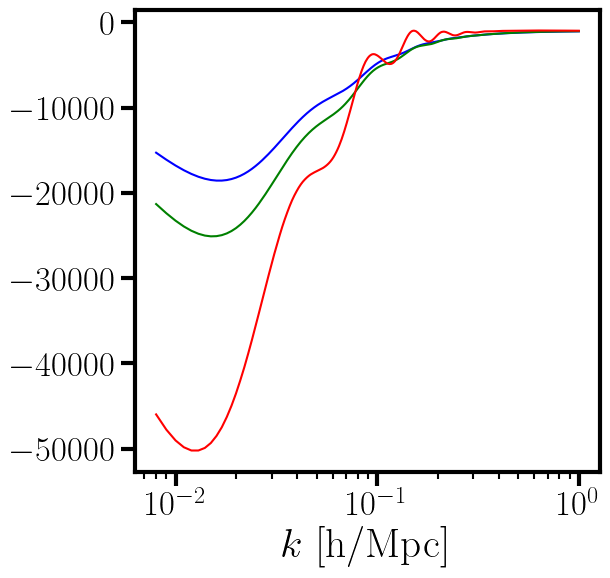

Pgg_alpha_parallel_74.txt


<Figure size 640x480 with 0 Axes>

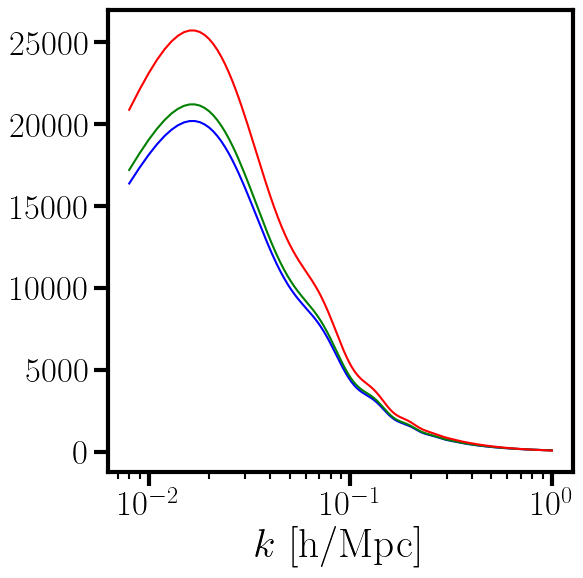

Pgg_bg_156.txt


<Figure size 640x480 with 0 Axes>

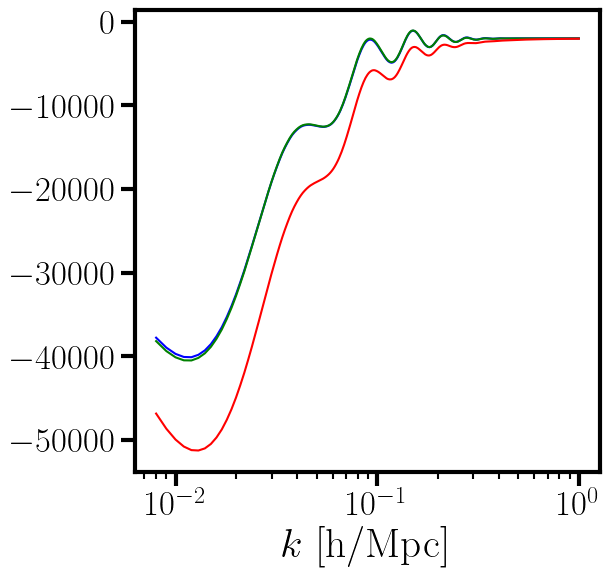

Pgg_alpha_perp_74.txt


<Figure size 640x480 with 0 Axes>

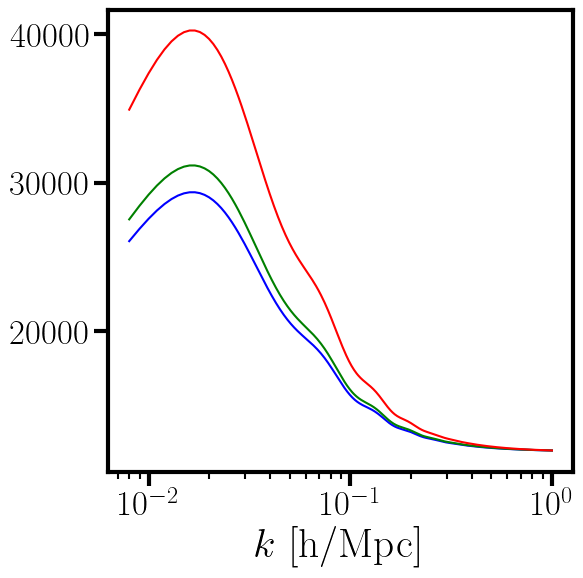

pfid_gg_156.txt


<Figure size 640x480 with 0 Axes>

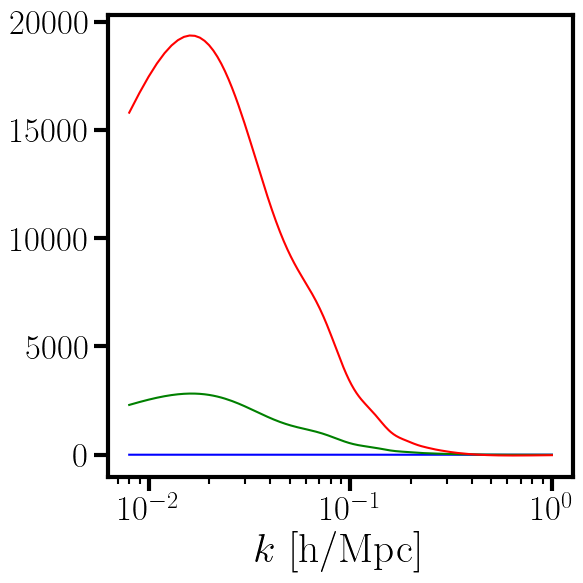

Pgg_f_74.txt


<Figure size 640x480 with 0 Axes>

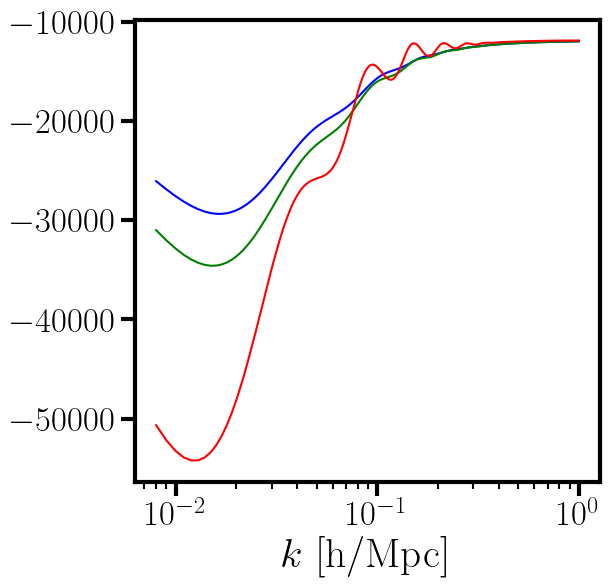

Pgg_alpha_parallel_156.txt


<Figure size 640x480 with 0 Axes>

In [16]:
lptforecast.check_derivatives()

In [17]:
%reload_ext autoreload
%autoreload 2

wsforecast.Sigma2(0)

np.float64(34.168281586998255)

In [18]:
%reload_ext autoreload
%autoreload 2

wsforecast.Sigma2(0)

np.float64(34.168281586998255)